# **Day 18: Feature Scaling and Encoding**
*Module 3 - Data Preparation and Feature Engineering*

Models see only numbers. Two questions for every column:
1. **Numerical**: are the scales comparable? Is the distribution very skewed?
2. **Categorical**: how do we turn text categories into numbers without inventing false order?

> Many models need features on similar scales, and text categories must be turned into numbers. Scaling (for example standardisation) and encoding (for example one-hot encoding) prepare the data so the model treats every feature fairly.
>
> *Example:* Elevation (0-3000 m) and NDVI (-1 to 1) on their raw scales make distance-based models such as kNN ignore NDVI. After scaling, both count equally.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(18)

## **1. Who Needs Scaling?**

| Needs scaling | Why | Does not need scaling |
|---|---|---|
| kNN, K-Means, SVM (RBF) | Distances are dominated by large-scale features | Decision trees, Random Forest |
| Linear/logistic regression with regularisation | Penalty treats all coefficients equally | Gradient boosting (XGBoost etc.) |
| Neural networks, PCA | Optimisation speed (Day 13); variance-based | Naive Bayes (per-feature) |

In [2]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

X, y = load_wine(return_X_y=True, as_frame=True)
print("Feature ranges:\n", X.agg(["min", "max"]).T.iloc[[0, 4, 12]])
for name, m in {"kNN": KNeighborsClassifier(), "SVM-RBF": SVC(), "Random Forest": RandomForestClassifier(random_state=0)}.items():
    raw = cross_val_score(m, X, y, cv=5).mean(); sc = cross_val_score(make_pipeline(StandardScaler(), m), X, y, cv=5).mean()
    print(f"{name:<14} raw {raw:.3f} -> scaled {sc:.3f}")

Feature ranges:
               min      max
alcohol     11.03    14.83
magnesium   70.00   162.00
proline    278.00  1680.00
kNN            raw 0.691 -> scaled 0.949
SVM-RBF        raw 0.663 -> scaled 0.983


Random Forest  raw 0.983 -> scaled 0.983


`proline` (hundreds to ~1700) dominates the distances of kNN and SVM. Trees split on one feature at a time, so scale does not matter.

## **2. The Scalers**

| Scaler | Formula | Use when |
|---|---|---|
| `StandardScaler` | $(x-\mu)/\sigma$ | Default for most models |
| `MinMaxScaler` | $(x-\min)/(\max-\min)$ | Need bounded range [0,1] (images, some NNs) |
| `RobustScaler` | $(x-\text{median})/IQR$ | Outliers present |
| `MaxAbsScaler` | $x/\max\lvert x\rvert$ | Sparse data (keeps zeros) |
| `Normalizer` | each **row** to unit norm | Text / spectra shape (cosine similarity) |

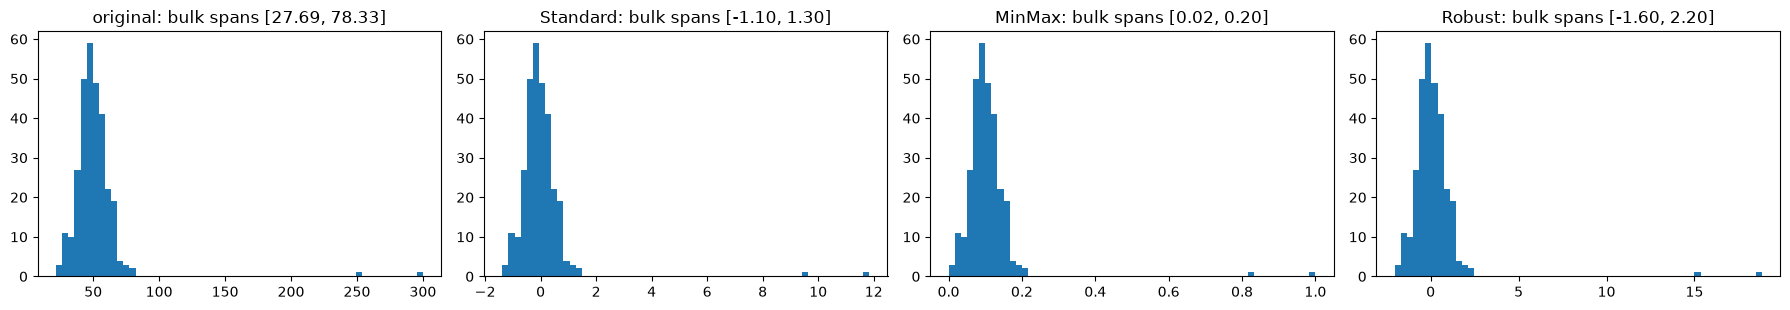

In [3]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler
feat = np.r_[rng.normal(50, 10, 300), [250, 300]].reshape(-1, 1)       # two outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax, (name, sc) in zip(axes, {"original": None, "Standard": StandardScaler(), "MinMax": MinMaxScaler(), "Robust": RobustScaler()}.items()):
    v = feat if sc is None else sc.fit_transform(feat)
    ax.hist(v, bins=60); ax.set_title(f"{name}: bulk spans [{np.percentile(v, 1):.2f}, {np.percentile(v, 99):.2f}]")
plt.tight_layout(); plt.show()

With MinMax, two outliers squeeze the normal data into a tiny range. RobustScaler keeps the bulk well spread.

**Golden rule:** `fit` the scaler on training data only, then `transform` train and test (do it with a pipeline).

## **3. Fixing Skewed Distributions**

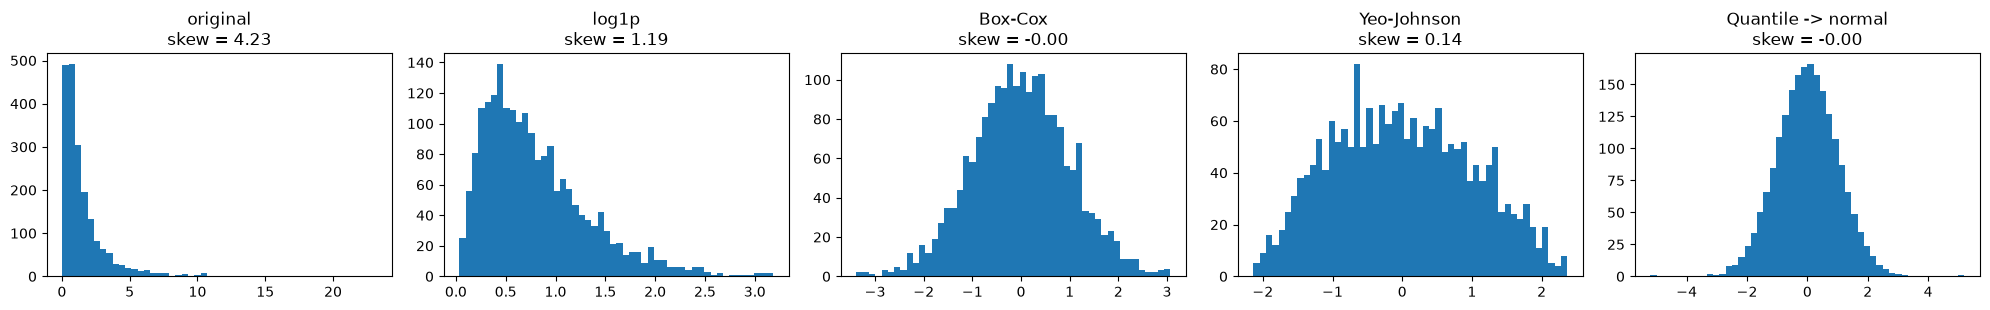

In [4]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
skewed = rng.lognormal(0, 1, 2000).reshape(-1, 1)
trans = {"original": skewed, "log1p": np.log1p(skewed),
         "Box-Cox": PowerTransformer(method="box-cox").fit_transform(skewed),
         "Yeo-Johnson": PowerTransformer(method="yeo-johnson").fit_transform(skewed),
         "Quantile -> normal": QuantileTransformer(output_distribution="normal", n_quantiles=500).fit_transform(skewed)}
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
from scipy.stats import skew
for ax, (k, v) in zip(axes, trans.items()):
    ax.hist(v, bins=50); ax.set_title(f"{k}\nskew = {skew(v.ravel()):.2f}")
plt.tight_layout(); plt.show()

Box-Cox needs strictly positive values; Yeo-Johnson works with zeros and negatives. Quantile transformation forces any distribution to normal/uniform (but distorts distances).

## **4. Encoding Categorical Features**

In [5]:
df = pd.DataFrame({"soil": ["clay", "loam", "sand", "loam", "clay", "silt"],
                   "quality": ["low", "high", "medium", "medium", "low", "high"],
                   "district": ["D1", "D2", "D3", "D2", "D9", "D1"]})
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(df[["soil"]])
print("One-hot:\n", pd.DataFrame(ohe.transform(df[["soil"]]), columns=ohe.get_feature_names_out()))
ord_enc = OrdinalEncoder(categories=[["low", "medium", "high"]])
print("\nOrdinal (with a meaningful order):", ord_enc.fit_transform(df[["quality"]]).ravel())
print("Unknown category at prediction time ->", ohe.transform(pd.DataFrame({"soil": ["peat"]})))

One-hot:
    soil_clay  soil_loam  soil_sand  soil_silt
0        1.0        0.0        0.0        0.0
1        0.0        1.0        0.0        0.0
2        0.0        0.0        1.0        0.0
3        0.0        1.0        0.0        0.0
4        1.0        0.0        0.0        0.0
5        0.0        0.0        0.0        1.0

Ordinal (with a meaningful order): [0. 2. 1. 1. 0. 2.]
Unknown category at prediction time -> [[0. 0. 0. 0.]]


| Encoding | Use for | Danger |
|---|---|---|
| One-hot | Nominal, few levels | Many columns for high cardinality |
| Ordinal | Ordered levels (low < medium < high) | Implies false order if used on nominal data (for linear models) |
| Frequency / count | High cardinality | Different categories with same frequency collide |
| Target (mean) encoding | High cardinality | **Target leakage** unless cross-fitted |

### Target encoding done right
Replace each category by the mean target **computed out-of-fold** (and smoothed towards the global mean for rare categories). scikit-learn's `TargetEncoder` does this cross-fitting automatically inside `fit_transform`.

In [6]:
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression

n = 3000
cats = rng.integers(0, 600, n)                                 # 600 levels, ~5 samples each
cat_effect = rng.normal(0, 1, 600)
y_cat = (rng.random(n) < 1 / (1 + np.exp(-(cat_effect[cats] + rng.normal(0, 1, n))))).astype(int)
Xc = pd.DataFrame({"village": cats.astype(str)})

def naive_target_encode(X_tr, y_tr, X_te):
    means = pd.Series(y_tr).groupby(X_tr.village.values).mean()
    return X_tr.village.map(means).values[:, None], X_te.village.map(means).fillna(y_tr.mean()).values[:, None]

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
Xa, Xb, ya, yb = train_test_split(Xc, y_cat, test_size=0.3, random_state=0)
tra, teb = naive_target_encode(Xa, ya, Xb)
naive = LogisticRegression().fit(tra, ya)
print(f"Naive target encoding: train AUC {roc_auc_score(ya, naive.predict_proba(tra)[:, 1]):.3f} | test AUC {roc_auc_score(yb, naive.predict_proba(teb)[:, 1]):.3f}")
te = TargetEncoder(cv=KFold(5, shuffle=True, random_state=0))
tra2 = te.fit_transform(Xa, ya); teb2 = te.transform(Xb)                # cross-fitted on train
good = LogisticRegression().fit(tra2, ya)
print(f"Cross-fitted encoder : train AUC {roc_auc_score(ya, good.predict_proba(tra2)[:, 1]):.3f} | test AUC {roc_auc_score(yb, good.predict_proba(teb2)[:, 1]):.3f}")

Naive target encoding: train AUC 0.857 | test AUC 0.625
Cross-fitted encoder : train AUC 0.622 | test AUC 0.625


The naive encoder lets each sample "see" its own label, so its **training** score is hugely inflated. (Test AUC is identical here only because, with a single feature, both encoders rank test samples the same way.) In a real model with other features, the leaky column looks far more reliable during training than it is, so the model over-trusts it and model selection is misled.

# **Part 2: Going Deeper**

### Cyclical features
Hour 23 and hour 0 are neighbours, but as numbers they are 23 apart. Encode cyclical variables as $(\sin\theta, \cos\theta)$. Same for day-of-year, month, wind direction and terrain **aspect**.

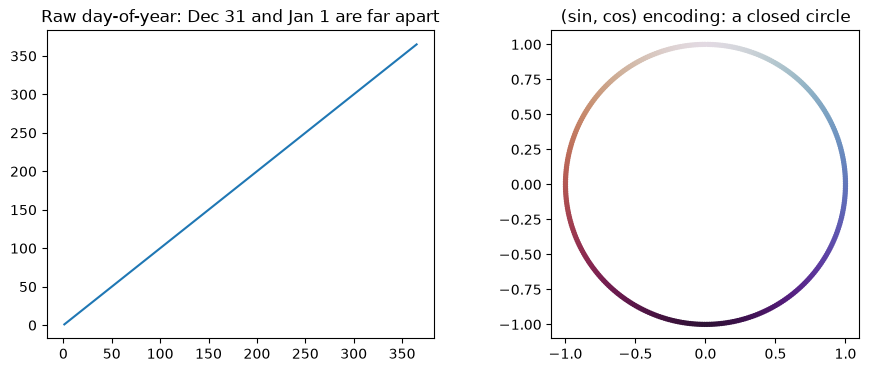

aspect 5 vs 355 deg distance, raw: 350 | encoded: 0.174


In [7]:
doy = np.arange(1, 366)
theta = 2 * np.pi * doy / 365.25
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(doy, doy); axes[0].set_title("Raw day-of-year: Dec 31 and Jan 1 are far apart")
axes[1].scatter(np.sin(theta), np.cos(theta), c=doy, cmap="twilight", s=8); axes[1].set_aspect("equal")
axes[1].set_title("(sin, cos) encoding: a closed circle")
plt.show()
aspect_deg = np.array([5, 355, 180])
print("aspect 5 vs 355 deg distance, raw:", abs(aspect_deg[0] - aspect_deg[1]),
      "| encoded:", np.linalg.norm([np.sin(np.radians(5)) - np.sin(np.radians(355)), np.cos(np.radians(5)) - np.cos(np.radians(355))]).round(3))

### The hashing trick
For millions of categories (user IDs, words), map each to one of $2^k$ columns with a hash function. No vocabulary to store; collisions are rare and usually harmless.

In [8]:
from sklearn.feature_extraction import FeatureHasher
h = FeatureHasher(n_features=16, input_type="string")      # signs (+1/-1) make collisions cancel on average
print(h.transform([["user_918273"], ["user_5"], ["user_918273"]]).toarray().astype(int))

[[ 0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0]]


## **Practice Problems**
1. On the wine data, compare kNN with `StandardScaler`, `MinMaxScaler`, `RobustScaler` and `QuantileTransformer` (5-fold CV).
2. Why must `OneHotEncoder(handle_unknown="ignore")` be used in production pipelines?
3. Encode `month` (1-12) cyclically and show that December and January are close.
4. *(Advanced)* Use `TargetEncoder` with `cv=5` vs `cv=2`. Does the test AUC change?

In [9]:
# Solution 1
from sklearn.preprocessing import QuantileTransformer
for sc in [StandardScaler(), MinMaxScaler(), RobustScaler(), QuantileTransformer(n_quantiles=100)]:
    print(f"{type(sc).__name__:<20} {cross_val_score(make_pipeline(sc, KNeighborsClassifier()), X, y, cv=5).mean():.3f}")
# Solution 3
mth = np.arange(1, 13); enc = np.c_[np.sin(2 * np.pi * mth / 12), np.cos(2 * np.pi * mth / 12)]
print("Dec-Jan distance:", np.linalg.norm(enc[11] - enc[0]).round(3), "| Jun-Jan:", np.linalg.norm(enc[5] - enc[0]).round(3))
# Solution 4
for cv in [2, 5]:
    e = TargetEncoder(cv=KFold(cv, shuffle=True, random_state=0)); a = e.fit_transform(Xa, ya)
    print(f"cv={cv}: test AUC {roc_auc_score(yb, LogisticRegression().fit(a, ya).predict_proba(e.transform(Xb))[:, 1]):.3f}")

StandardScaler       0.949

MinMaxScaler         0.950
RobustScaler         0.938
QuantileTransformer  0.950
Dec-Jan distance: 0.518 | Jun-Jan: 1.932
cv=2: test AUC 0.625
cv=5: test AUC 0.625


**Solution 2:** new categories appear in production (a new district, a new product). Without `ignore`, the pipeline crashes.

## **Key References**
- Box, G. E. P., & Cox, D. R. (1964). An analysis of transformations. *Journal of the Royal Statistical Society B*, 26(2), 211-252.
- Yeo, I.-K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika*, 87(4), 954-959.
- Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes. *ACM SIGKDD Explorations*, 3(1), 27-32.
- Weinberger, K. et al. (2009). Feature hashing for large scale multitask learning. *ICML 2009*.
- Pargent, F., Pfisterer, F., Thomas, J., & Bischl, B. (2022). Regularized target encoding outperforms traditional methods in supervised machine learning with high cardinality features. *Computational Statistics*, 37, 2671-2692.